In [1]:
%load_ext autoreload
%autoreload 2
%load_ext line_profiler
import moabb
from moabb.datasets import *
from moabb.paradigms import P300
from hoda.hoda import HODA
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from sklearn.manifold import TSNE
from mne.decoding import Scaler
from mne import combine_evoked

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
fmax=16
sfreq=64
paradigm = P300(resample=sfreq, tmin=-0.2, tmax=1.0, fmin=0.5, fmax=fmax)
#dataset = EPFLP300()
#subject, session, run = 1, "session_1", "run_1"
dataset = BNCI2014009()
subject, session, run = 1, "session_0", "run_0"


In [3]:
dataset.download(subject_list=[subject])
data = dataset.get_data(subjects=[subject])
raw = data[subject][session][run]
raw.info
epochs, labels, _ = paradigm.process_raw(raw, dataset, return_epochs=True)
epochs

Creating RawArray with float64 data, n_channels=18, n_times=50184
    Range : 0 ... 50183 =      0.000 ...   196.027 secs
Ready.
Creating RawArray with float64 data, n_channels=18, n_times=50184
    Range : 0 ... 50183 =      0.000 ...   196.027 secs
Ready.
Creating RawArray with float64 data, n_channels=18, n_times=50184
    Range : 0 ... 50183 =      0.000 ...   196.027 secs
Ready.
Not setting metadata
576 matching events found
No baseline correction applied


Number of events,576
Events,NonTarget: 480Target: 96
Time range,-0.203 – 0.984 sec
Baseline,off


In [4]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl

tl.set_backend('numpy')

X = epochs.get_data()
y = labels

X.shape

(576, 16, 77)

In [5]:
from hoda.hoda import BTTDA
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import Scaler

n_blocks=4
bttda = BTTDA(
    n_blocks=n_blocks,
    hoda_params=dict(
            rank=None,
            max_iter=256,
            tol=1e-3,
            init ='mlsvd',
            verbose=True,
            shrinkage=('lw','lw'),
            toeplitz=(1,),
            solver='lfl',
            keep_train_info=True,
            taper=False,
            #solver_params=dict(psi=0.1),
    ),
    keep_train_info=True,
    verbose=True)                   

bttda.fit(X,y)

Fitting block 1/4...
Initializing factors...
Fitting discriminative tucker model of rank [2, 2] ...


  0%|          | 0/256 [00:00<?, ?it/s]


Fitting block 2/4...
Initializing factors...
Fitting discriminative tucker model of rank [3, 3] ...


  0%|          | 0/256 [00:00<?, ?it/s]


Fitting block 3/4...
Initializing factors...
Fitting discriminative tucker model of rank [9, 4] ...


  0%|          | 0/256 [00:00<?, ?it/s]


Fitting block 4/4...
Initializing factors...
Fitting discriminative tucker model of rank [6, 3] ...


  0%|          | 0/256 [00:00<?, ?it/s]

BTTDA(hoda_params={'init': 'mlsvd', 'keep_train_info': True, 'max_iter': 256,
                   'rank': None, 'shrinkage': ('lw', 'lw'), 'solver': 'lfl',
                   'taper': False, 'toeplitz': (1,), 'tol': 0.001,
                   'verbose': True},
      keep_train_info=True, n_blocks=4, verbose=True)

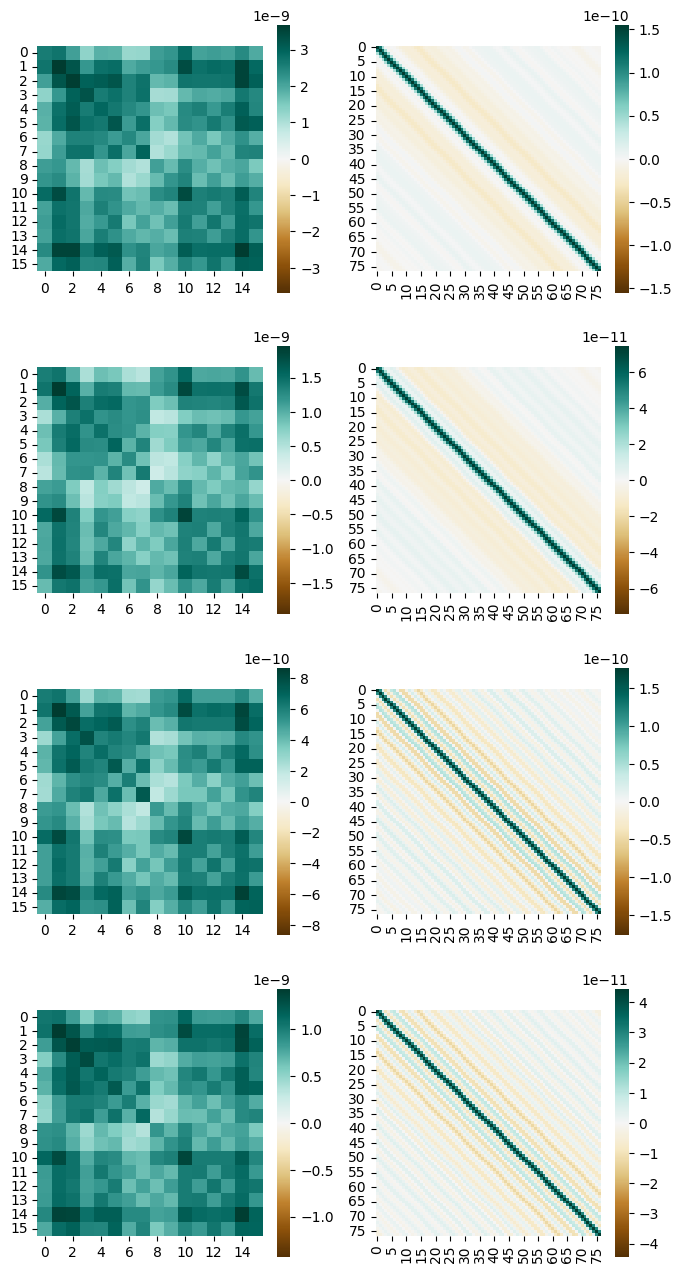

In [6]:
import cupy

fig, axs = plt.subplots(n_blocks, 2, figsize=(8,16))
for b in range(n_blocks):
    for k in range(2):
        scatter_w = cupy.asnumpy(bttda.blocks_[b].scatter_w_[k])
        vmax = np.max(np.abs(scatter_w))
        sns.heatmap(scatter_w, cmap='BrBG',
                    vmin=-vmax, vmax=vmax, ax=axs[b,k])    
        axs[b,k].set_aspect('equal')

No projector specified for this dataset. Please consider the method self.add_proj.


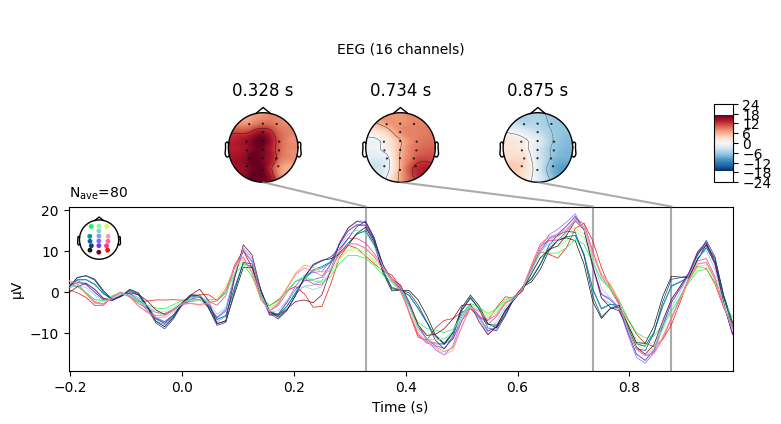

In [10]:
X_defl = X.copy()
for b in range(1):
    Xt = bttda.blocks_[k].transform(X_defl)
    epochs_approx = epochs.copy()
    epochs_approx._data = bttda.blocks_[k].inv_transform(Xt)

    target = epochs_approx['Target'].average()
    non_target = epochs_approx['NonTarget'].average()
    contrast = combine_evoked([target, non_target], weights=[1,-1])
    _= contrast.plot_joint()
    
    #epochs_defl._data -= epochs_approx._data


In [8]:
import pandas as pd
import cupy

train_scores = cupy.asnumpy(bttda_lda.decision_function(X_train))
df = pd.DataFrame(dict(score=cupy.asnumpy(train_scores),label=labels_train))
sns.histplot(data=df, x='score', hue='label')

NameError: name 'bttda_lda' is not defined

In [ ]:
roc_auc_score(y_train,train_scores)

In [ ]:
test_scores = cupy.asnumpy(bttda_lda.decision_function(X_test))
df = pd.DataFrame(dict(score=cupy.asnumpy(test_scores),label=labels_test))
sns.histplot(data=df, x='score', hue='label')

In [ ]:
roc_auc_score(y_test,test_scores)